In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'

# Set number of classes

In [3]:
NUM_CLASSES = 18

# Dataset reading

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.80, random_state=RANDOM_SEED) 
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 158094 samples
Testing set size: 39524 samples


# Model Building

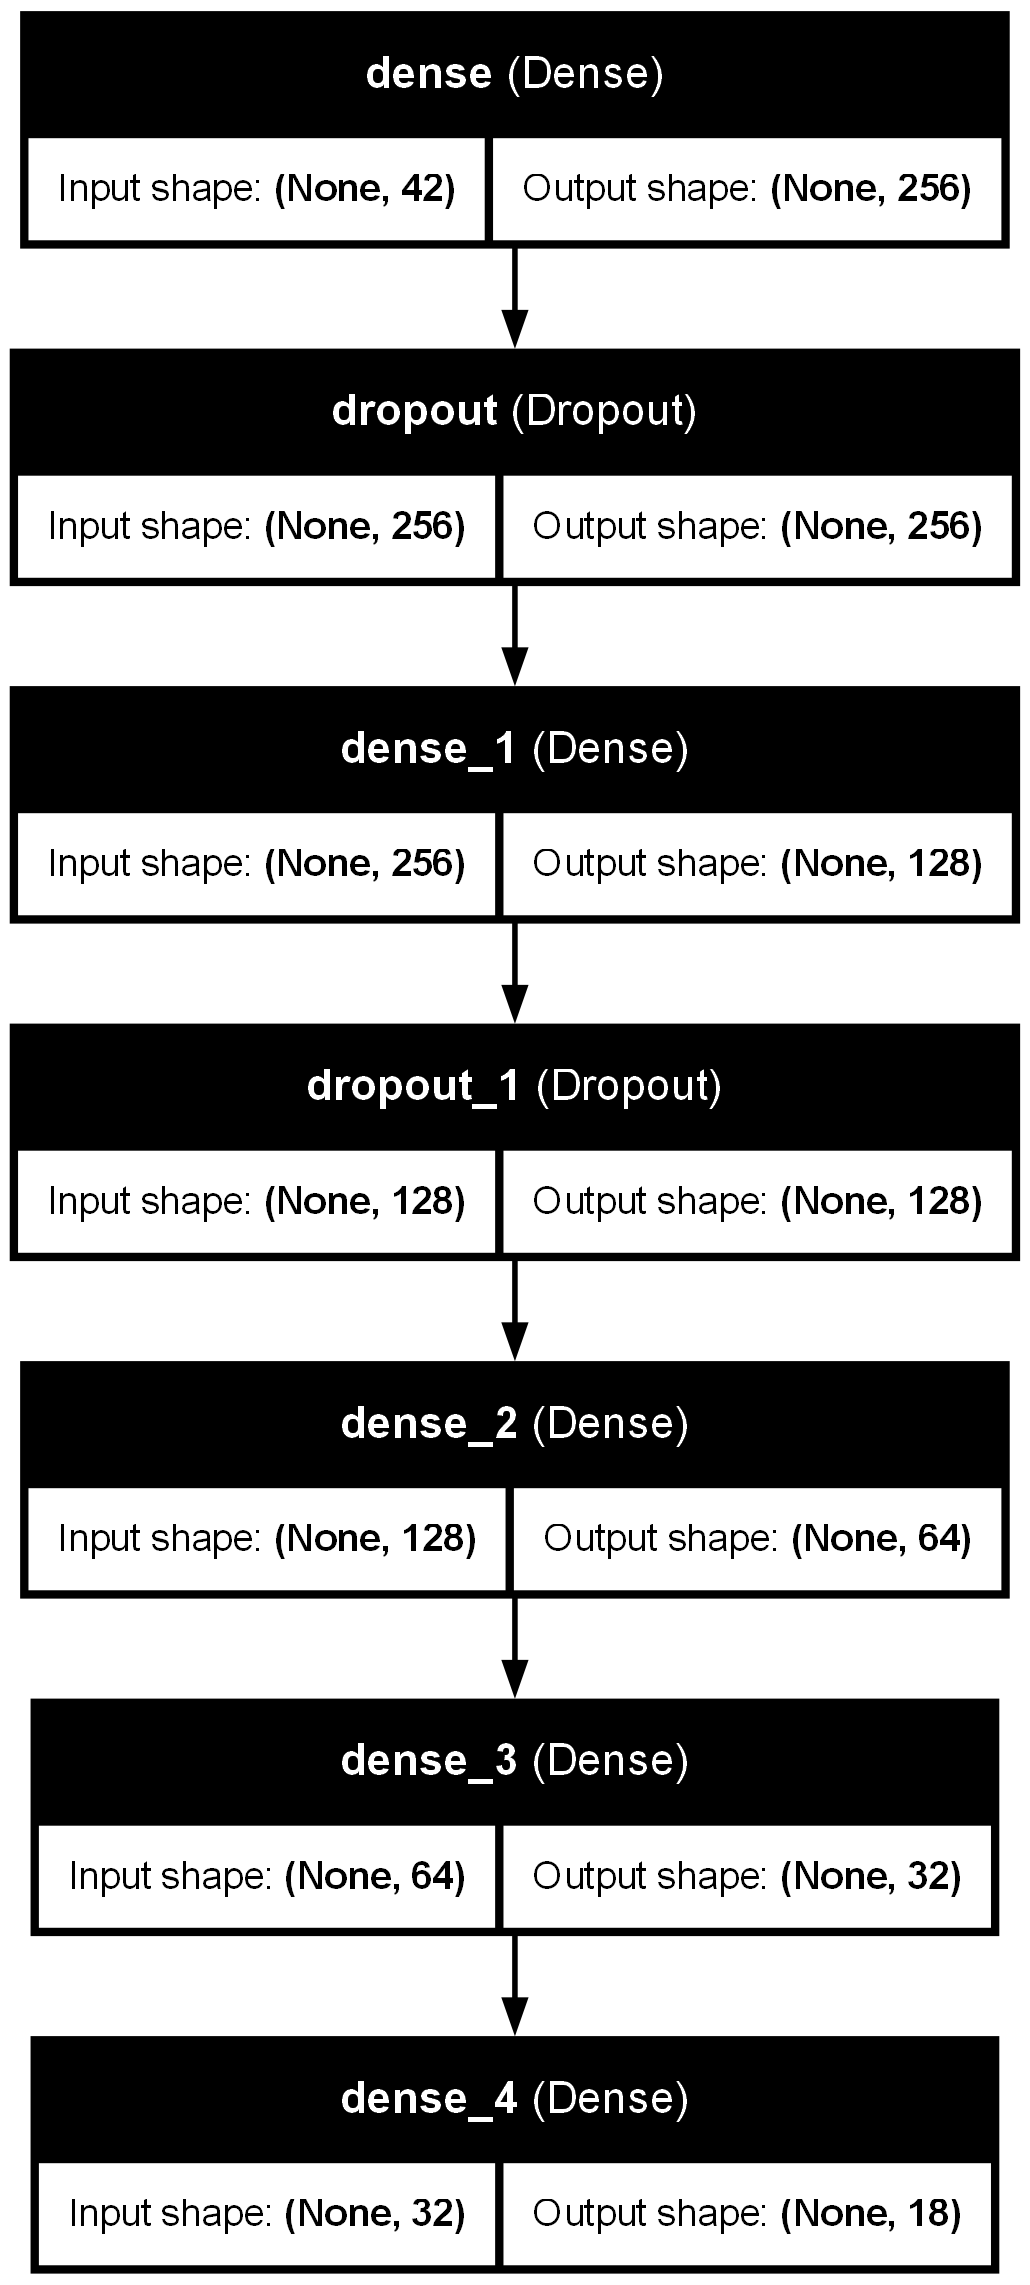

In [7]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
import tensorflow as tf
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((42, )),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.10),
    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])


plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │          11,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 18)                  │             594 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 54,834 (214.20 KB)

 Trainable params: 54,834 (214.20 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',  # Can also use 'val_loss'
    patience=5,             # Number of epochs to wait before stopping
    verbose=1,
    restore_best_weights=True  # Optional: restore best weights
)

In [10]:
initial_learning_rate = 0.001  # Keep starting at 0.001
decay_steps = 800              # Quicker decay
decay_rate = 0.95              # Steeper drop
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=False  # Keep smooth decay
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}


In [12]:
# Custom callback to log learning rate at the end of each epoch
# List to store learning rates
lrs = []
class LRTensorBoard(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        lrs.append(lr)

        

# Model Training

In [13]:
# Model Training
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=512,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback, LRTensorBoard()],  # Add LR callback
    class_weight=class_weight_dict  # I added this one to fix the precision of dislike
)



Epoch 1/40
303/309 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4586 - loss: 1.7394
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras
309/309 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4629 - loss: 1.7252 - val_accuracy: 0.8523 - val_loss: 0.5299
Epoch 2/40
306/309 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8487 - loss: 0.5210
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8489 - loss: 0.5205 - val_accuracy: 0.8870 - val_loss: 0.3992
Epoch 3/40
298/309 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8803 - loss: 0.4147
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8804 - loss: 0.4143 - val_accuracy: 0.8922 - val_loss: 0.3672
Epoch 4/40
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8894 - loss: 0.3809
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.ker

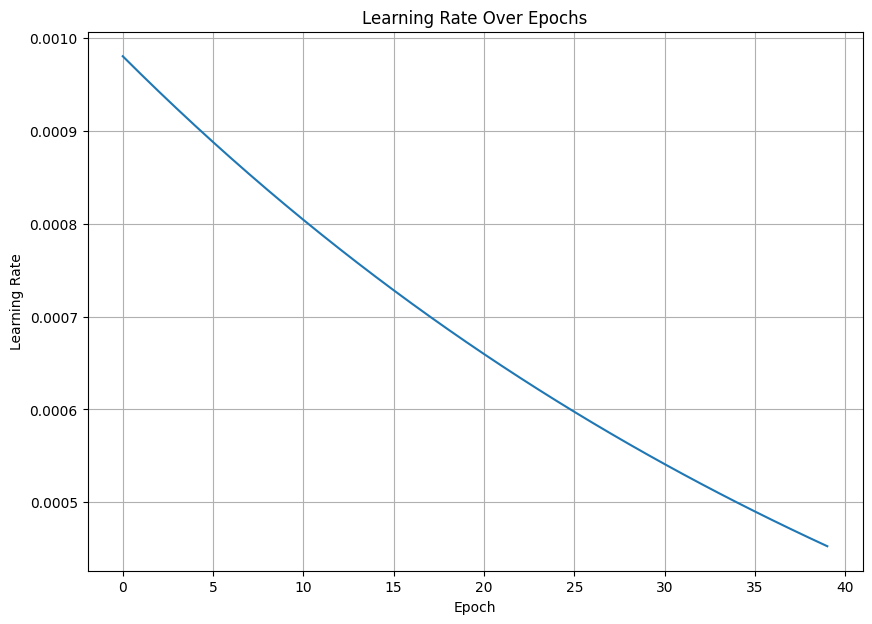

In [14]:

import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.plot(range(len(lrs)), lrs)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Over Epochs")
plt.grid(True)
plt.show()

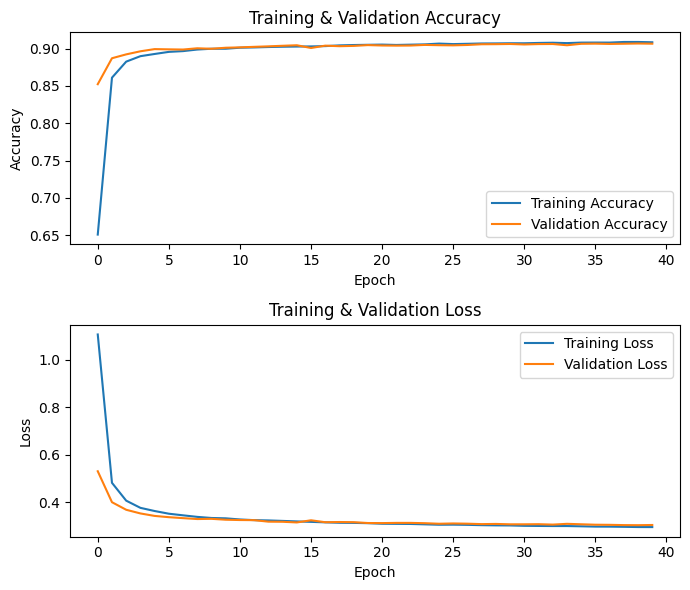

In [15]:
import matplotlib.pyplot as plt
#To show below the learning curve
plt.figure(figsize=(7, 6))

# Accuracy plot
plt.subplot(2, 1, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(2, 1, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [16]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9060 - loss: 0.3062


In [17]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [18]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
[9.7280963e-07 8.4062371e-08 1.2962976e-06 3.7911013e-03 1.1719400e-07
 1.6091434e-07 4.9983797e-04 1.9103848e-06 9.9344432e-01 6.2169516e-07
 2.5773006e-05 6.7007358e-07 9.1954041e-07 1.8947490e-03 3.0064202e-04
 3.3542379e-05 1.6588261e-06 1.6337206e-06]
8


# Confusion matrix

1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9059 - loss: 0.3077
Test Loss: 0.3030
Test Accuracy: 0.9065
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


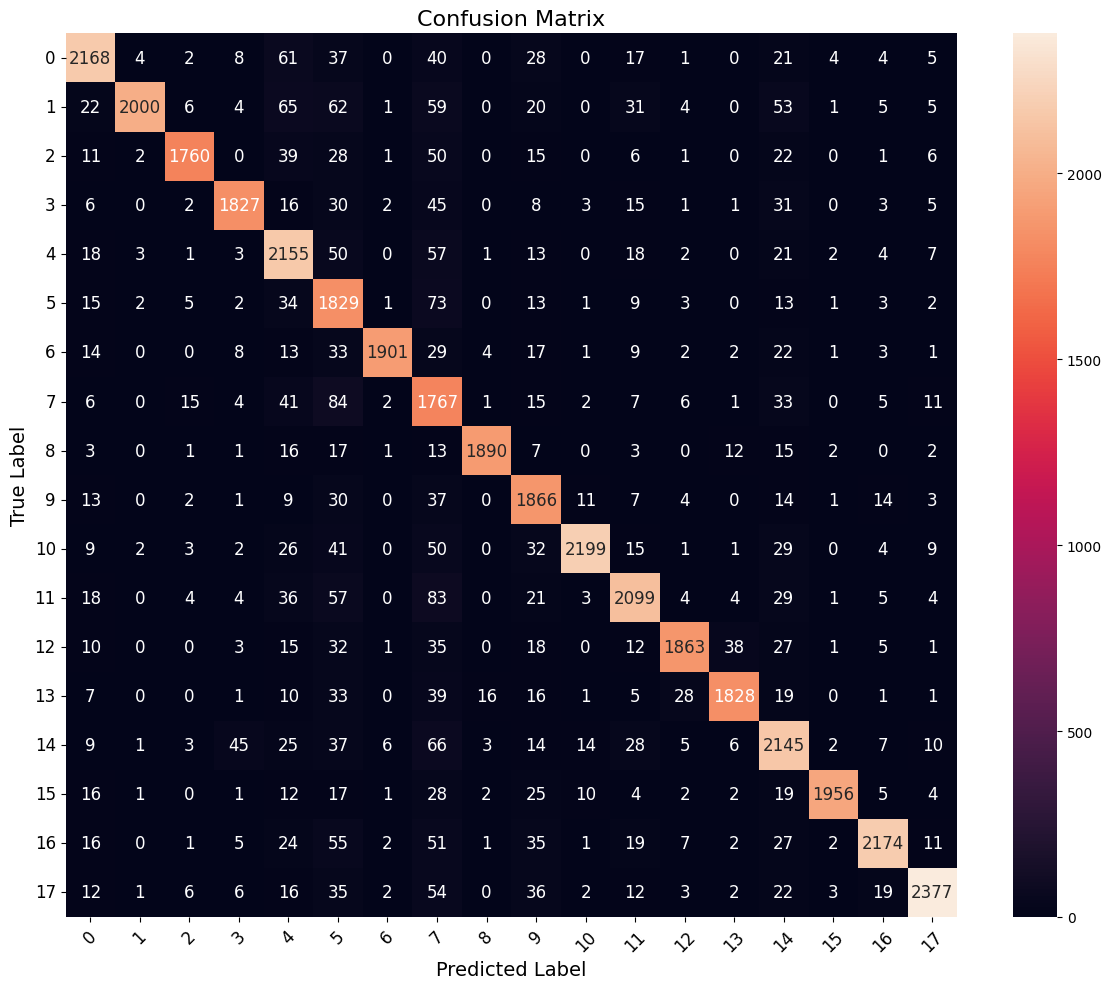

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      2400
           1       0.99      0.86      0.92      2338
           2       0.97      0.91      0.94      1942
           3       0.95      0.92      0.93      1995
           4       0.82      0.92      0.87      2355
           5       0.73      0.91      0.81      2006
           6       0.99      0.92      0.96      2060
           7       0.69      0.88      0.77      2000
           8       0.99      0.95      0.97      1983
           9       0.85      0.93      0.89      2012
          10       0.98      0.91      0.94      2423
          11       0.91      0.88      0.90      2372
          12       0.96      0.90      0.93      2061
          13       0.96      0.91      0.94      2005
          14       0.84      0.88      0.86      2426
          15       0.99      0.93      0.96      2105
          16       0.96      0.89      0.93      2433
     

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    # Change figure size for bigger boxes
    fig, ax = plt.subplots(figsize=(12, 10))  # Increased from (7, 6)
    
    # Add font size for annotations
    sns.heatmap(df_cmx, annot=True, fmt='g', square=False, 
                xticklabels=labels, yticklabels=labels,
                annot_kws={"size": 12})  # Larger font for numbers
    
    ax.set_xlabel('Predicted Label', fontsize=14)
    ax.set_ylabel('True Label', fontsize=14)
    ax.set_title('Confusion Matrix', fontsize=16)
    ax.set_xticklabels(labels, fontsize=12, rotation=45)
    ax.set_yticklabels(labels, fontsize=12, rotation=0)
    ax.set_ylim(len(labels), 0)  # slight fix (use labels)
    plt.tight_layout()  # Fit everything nicely
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

# Count  Loss & Accuracy on X_test
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Y_pred = model.predict(X_test)

# Define custom thresholds per class
custom_thresholds = {1: 0.5}  # 60% for 'dislike', 40% for 'rock'

y_pred = []
for probs in Y_pred:
    max_class = np.argmax(probs)
    if max_class in custom_thresholds and probs[max_class] < custom_thresholds[max_class]:
        # If the top prediction is below its threshold, pick next best
        sorted_probs = np.argsort(probs)
        second_best = sorted_probs[-2]
        y_pred.append(second_best)
    else:
        y_pred.append(max_class)

print_confusion_matrix(y_test, y_pred)


1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy: 0.9065
Sensitivity (Recall - Macro Avg): 0.9073
Specificity (Average): 0.9945
F1 Score (Macro Avg): 0.9090


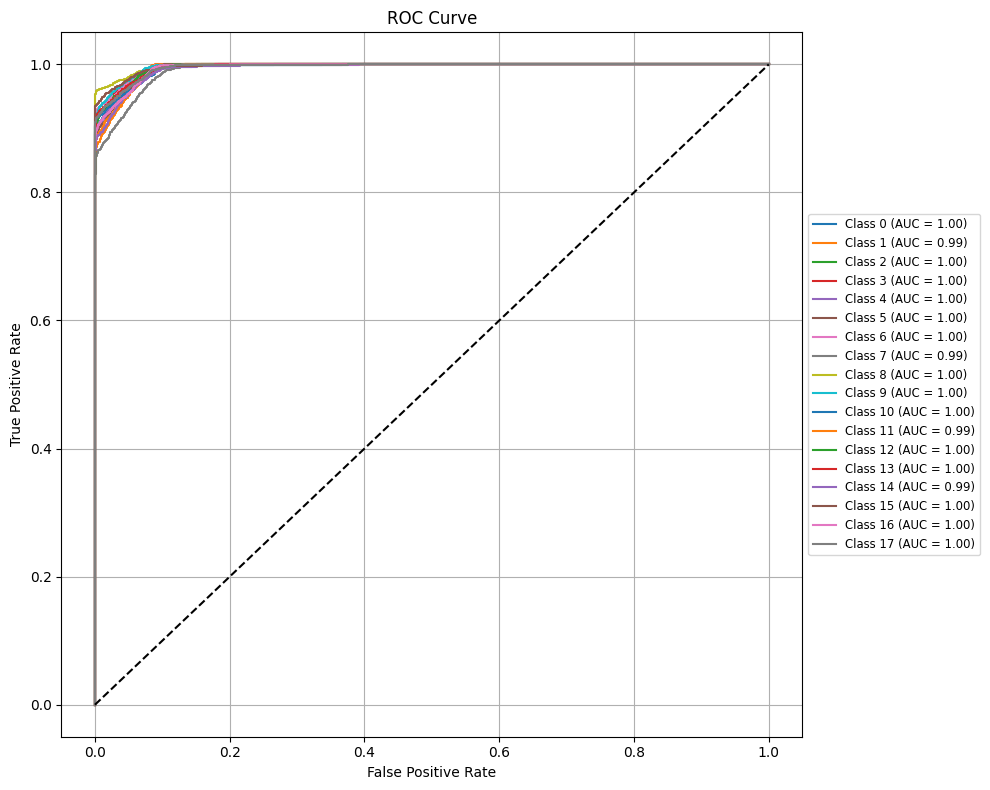

In [28]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. Predict labels
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels

# 2. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# 3. Sensitivity (Recall) - for each class
recall = recall_score(y_test, y_pred, average='macro')  # or 'weighted'
print(f"Sensitivity (Recall - Macro Avg): {recall:.4f}")

# 4. Specificity - calculate manually
cm = confusion_matrix(y_test, y_pred)
specificity_per_class = []
for i in range(cm.shape[0]):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    specificity = tn / (tn + fp)
    specificity_per_class.append(specificity)
specificity = np.mean(specificity_per_class)
print(f"Specificity (Average): {specificity:.4f}")

# 5. F1 Score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"F1 Score (Macro Avg): {f1:.4f}")

# 6. ROC Curve and AUC - one-vs-rest
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = len(np.unique(y_test))

# Convert y_test to one-hot if needed
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))  

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

#  Adjust legend: place it outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')  

plt.grid(True)
plt.tight_layout()  # Ensures everything fits nicely
plt.show()

# Convert to model for Tensorflow-Lite

In [21]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [22]:
# Transform model (quantization)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\arest\AppData\Local\Temp\tmpbs60kqni\assets


INFO:tensorflow:Assets written to: C:\Users\arest\AppData\Local\Temp\tmpbs60kqni\assets


Saved artifact at 'C:\Users\arest\AppData\Local\Temp\tmpbs60kqni'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  3109012350032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3109012344080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3109012348112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3109012350992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3109012348496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3109012352720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3109012351760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3109012353680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3109012352528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3109012354640: TensorSpec(shape=(), dtype=tf.resource, name=None)


66768

# Inference Test

In [23]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

C:\Users\arest\AppData\Roaming\Python\Python312\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [24]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [25]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [26]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [27]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[8.80019059e-07 7.65434365e-08 1.16586364e-06 3.52848740e-03
 1.06713635e-07 1.37379430e-07 4.73450025e-04 1.80363725e-06
 9.93580461e-01 5.47935258e-07 2.36567012e-05 6.77953892e-07
 8.68967277e-07 2.08334485e-03 2.67441064e-04 3.36806515e-05
 1.61478522e-06 1.56308374e-06]
8
